# Market, done right: a turbulence forecast we can trust

*Notebook for Section 4. Section 3 left us with a modest, honest edge on the market's volatility. Here we build it into something genuinely useful: a next-day forecast of whether tomorrow is likely to be a turbulent (big-move) day, so a risk-aware holder can lighten up, like a sailor reefing the sail before rough seas. Everything is produced here (numpy + matplotlib only). We do NOT predict direction and we do NOT trade; we forecast roughness, honestly.*

## a. What are we actually trying to build?

We stop chasing "predict the market" (Section 3 killed that) and ask what we can honestly, usefully do. The one thing the data supports is the SIZE of tomorrow's move (volatility clusters). And a real forecast speaks in probabilities, not yes or no. So the tool outputs a probability that tomorrow is a big-move day.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
import numpy as np, os
import matplotlib.pyplot as plt

ACCENT, MUTED, RED, GRID = "#3a6ea5", "#b8c0cc", "#c85a52", "#eef1f4"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.edgecolor": "#8a94a3", "axes.linewidth": 0.8})
def clean(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(True, color=GRID, linewidth=1); ax.set_axisbelow(True)
FIG  = "figures" if os.path.isdir("figures") else "../figures"
DATA = "data/gspc_2026-07-03.csv" if os.path.exists("data/gspc_2026-07-03.csv") else "../data/gspc_2026-07-03.csv"

# ---- same task as Section 3: from the last five move-sizes, is tomorrow a big-move day? ----
close = np.loadtxt(DATA, skiprows=1)
r = np.diff(close) / close[:-1]
s = np.abs(r)
L = 5
X = np.column_stack([s[i:len(s) - L + i] for i in range(L)])
fut = s[L:]; X = X[:len(fut)]
med = float(np.median(s))
y = (fut > med).astype(int)
N = len(y)
SEEDS = (0, 1, 2)

# ---- generic feed-forward network (any hidden layers), softmax + cross-entropy ----
def init_net(sizes, rng, scale=0.1):
    return [[rng.standard_normal((a, b)) * scale, np.zeros(b)] for a, b in zip(sizes[:-1], sizes[1:])]
def forward(Xb, P):
    a = Xb; caches = []
    for i, (W, b) in enumerate(P):
        z = a @ W + b; caches.append((a, z))
        a = np.maximum(z, 0.0) if i < len(P) - 1 else z
    return a, caches
def softmax(z):
    z = z - z.max(1, keepdims=True); e = np.exp(z); return e / e.sum(1, keepdims=True)
def ce_loss(logits, yb):
    p = softmax(logits); n = len(yb); return float(-np.log(p[np.arange(n), yb] + 1e-12).mean())
def backward(P, caches, logits, yb):
    n = len(yb); K = logits.shape[1]; Y = np.zeros((n, K)); Y[np.arange(n), yb] = 1.0
    dz = (softmax(logits) - Y) / n; grads = [None] * len(P)
    for i in reversed(range(len(P))):
        a_prev, z = caches[i]; W, b = P[i]; grads[i] = [a_prev.T @ dz, dz.sum(0)]
        if i > 0:
            da = dz @ W.T; _, z_prev = caches[i - 1]; dz = da * (z_prev > 0)
    return grads
def train_net(Xtr, ytr, sizes, rng, opt="gd", lr=0.3, epochs=300, mom=0.9,
              b1=0.9, b2=0.999, eps=1e-8, record=False):
    P = init_net(sizes, rng)
    vel = [[np.zeros_like(W), np.zeros_like(b)] for W, b in P]
    m = [[np.zeros_like(W), np.zeros_like(b)] for W, b in P]
    v = [[np.zeros_like(W), np.zeros_like(b)] for W, b in P]
    hist = []
    for e in range(1, epochs + 1):
        logits, caches = forward(Xtr, P)
        if record: hist.append(ce_loss(logits, ytr))
        grads = backward(P, caches, logits, ytr)
        for i in range(len(P)):
            for j in range(2):
                g = grads[i][j]
                if opt == "gd":
                    P[i][j] = P[i][j] - lr * g
                elif opt == "momentum":
                    vel[i][j] = mom * vel[i][j] - lr * g; P[i][j] = P[i][j] + vel[i][j]
                elif opt == "adam":
                    m[i][j] = b1 * m[i][j] + (1 - b1) * g; v[i][j] = b2 * v[i][j] + (1 - b2) * (g * g)
                    mh = m[i][j] / (1 - b1 ** e); vh = v[i][j] / (1 - b2 ** e)
                    P[i][j] = P[i][j] - lr * mh / (np.sqrt(vh) + eps)
    return P, hist
def standardize(Xtr, Xte):
    mu, sd = Xtr.mean(0), Xtr.std(0) + 1e-9; return (Xtr - mu) / sd, (Xte - mu) / sd
def accuracy(P, Xb, yb):
    lg, _ = forward(Xb, P); return float((lg.argmax(1) == yb).mean())
def proba1(P, Xb):
    lg, _ = forward(Xb, P); return softmax(lg)[:, 1]
def wf_acc(hidden, opt="gd", lr=0.3, epochs=300, folds=5, seeds=SEEDS):
    n = N; bs = n // (folds + 1); accs = []
    for k in range(1, folds + 1):
        tr = np.arange(0, k * bs); te = np.arange(k * bs, (k + 1) * bs)
        Xtr, Xte = standardize(X[tr], X[te])
        a = [accuracy(train_net(Xtr, y[tr], [L] + hidden + [2], np.random.default_rng(sd), opt, lr, epochs)[0], Xte, y[te]) for sd in seeds]
        accs.append(float(np.mean(a)))
    return float(np.mean(accs)), accs

# chronological 60/20/20 split (used for the search + calibration)
ntest = N // 5; nval = N // 5
i_tr = np.arange(0, N - ntest - nval); i_va = np.arange(N - ntest - nval, N - ntest); i_te = np.arange(N - ntest, N)

print(f"task: {N} days, busy share {y.mean():.3f} (a coin at 0.5). Output will be a PROBABILITY of a big-move day.")
# one day's forecast, as a probability
Xtr0, Xte0 = standardize(X[i_tr], X[i_te])
P0, _ = train_net(Xtr0, y[i_tr], [L, 16, 2], np.random.default_rng(0), "gd", 0.3, 300)
pex = proba1(P0, Xte0)
print(f"example: for the first sealed-test day, P(tomorrow is a big-move day) = {pex[0]:.2f}")

task: 6658 days, busy share 0.500 (a coin at 0.5). Output will be a PROBABILITY of a big-move day.


example: for the first sealed-test day, P(tomorrow is a big-move day) = 0.53


## b. How good could this get, and what won't it do?

Before building anything fancy, we ask how good it CAN get. The ceiling is set by the signal in the data, not by our cleverness, so we estimate it first with trivial baselines. If a fancy model later sits far above this line, that is not a triumph, it is a warning of a leak.

And we state the limits up front, because naming them is what makes a modest forecast trustworthy: **tomorrow only**, **size not direction** (so it cannot be used to trade for profit, only to manage risk), **a tilt not a certainty** (wrong about a third of the time), **one index, one history**, and **past-based**, so it has an expiry and must be re-checked as the world drifts.

persistence (yesterday big -> today big): 0.555
logistic regression on 5 lags          : 0.592
the Section 3 network (1x16)           : 0.603
=> the honest ceiling for this task is about 0.59. Anything far above it would be a leak.


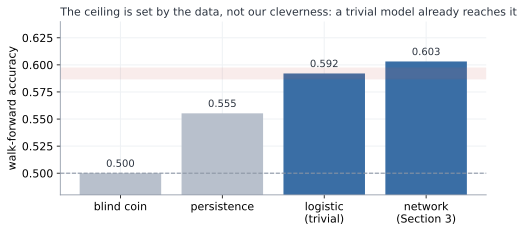

In [2]:
# ---- estimate the CEILING with trivial baselines, walk-forward (before any deep learning) ----
def wf_persistence(folds=5):
    n = N; bs = n // (folds + 1); accs = []
    for k in range(1, folds + 1):
        tr = np.arange(0, k * bs); te = np.arange(k * bs, (k + 1) * bs)
        thr = np.median(X[tr, -1]); accs.append(float(((X[te, -1] > thr).astype(int) == y[te]).mean()))
    return float(np.mean(accs))
PERS = wf_persistence()
LOGI, _ = wf_acc([], "gd", 0.3, 300)            # no hidden layer = logistic regression
BASE, base_folds = wf_acc([16], "gd", 0.3, 300)  # the Section 3 network
print(f"persistence (yesterday big -> today big): {PERS:.3f}")
print(f"logistic regression on 5 lags          : {LOGI:.3f}")
print(f"the Section 3 network (1x16)           : {BASE:.3f}")
print(f"=> the honest ceiling for this task is about {max(PERS, LOGI):.2f}. Anything far above it would be a leak.")

fig, ax = plt.subplots(figsize=(7.0, 3.4))
names = ["blind coin", "persistence", "logistic\n(trivial)", "network\n(Section 3)"]
vals = [0.5, PERS, LOGI, BASE]
cols = [MUTED, MUTED, ACCENT, ACCENT]
ax.bar(names, vals, color=cols)
for i, vv in enumerate(vals):
    ax.text(i, vv + 0.004, f"{vv:.3f}", ha="center", va="bottom", fontsize=10, color="#2b333f")
ax.axhline(0.5, color="#8a94a3", lw=1.1, ls="--")
ax.axhspan(max(PERS, LOGI) - 0.005, max(PERS, LOGI) + 0.005, color=RED, alpha=0.12)
ax.set_ylim(0.48, 0.64); ax.set_ylabel("walk-forward accuracy")
ax.set_title("The ceiling is set by the data, not our cleverness: a trivial model already reaches it",
             loc="left", fontsize=11, color="#2b333f")
clean(ax); fig.tight_layout(); fig.savefig(f"{FIG}/m4_ceiling.svg", bbox_inches="tight"); plt.show()

## c. Building it, and this time the steps just work

Every lesson from Section 3, applied now as a calm checklist: split past to future so nothing leaks, scale without peeking so nothing drifts, then the same small network, only now it emits a probability. What took all of Section 3 to discover in pain is routine here.

In [3]:
# ---- build it the honest way (every Section 3 lesson), report the number we can stand on ----
chron = float(np.mean([accuracy(train_net(Xtr0, y[i_tr], [L, 16, 2], np.random.default_rng(sd), "gd", 0.3, 300)[0], Xte0, y[i_te]) for sd in SEEDS]))
print("split past->future (no leak), scale without peeking (no drift), same little network, now emitting a probability:")
print(f"  chronological single split, sealed test: {chron:.3f}")
print(f"  walk-forward (era-aware, five moments)  : {BASE:.3f}   folds {[round(x,3) for x in base_folds]}")
print("  -> right at the ceiling, exactly as Section 3 found. The relief: every step just works now.")

split past->future (no leak), scale without peeking (no drift), same little network, now emitting a probability:
  chronological single split, sealed test: 0.586
  walk-forward (era-aware, five moments)  : 0.603   folds [0.525, 0.603, 0.651, 0.654, 0.583]
  -> right at the ceiling, exactly as Section 3 found. The relief: every step just works now.


## d. Bringing out the whole toolkit

Now we unleash the full deep-learning kit, but with discipline: the goal is to reliably REACH the ceiling, never to break it. We compare architectures and optimisers, then run an honest hyperparameter search, declaring the budget, choosing on validation, and opening the sealed test exactly once.

  1x16 (Section 3)    : 0.603


  1x64 (wider)        : 0.602


  2x(32,16) (deeper)  : 0.602
  -> capacity buys essentially nothing. The lever is not the size of the net.


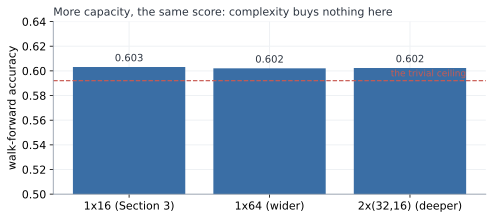

In [4]:
# ---- >=2 architectures: does more capacity help? ----
archs = [("1x16 (Section 3)", [16]), ("1x64 (wider)", [64]), ("2x(32,16) (deeper)", [32, 16])]
arch_acc = []
for name, hid in archs:
    a, _ = wf_acc(hid, "gd", 0.3, 300); arch_acc.append(a)
    print(f"  {name:20s}: {a:.3f}")
print("  -> capacity buys essentially nothing. The lever is not the size of the net.")

fig, ax = plt.subplots(figsize=(7.0, 3.2))
ax.bar([n for n, _ in archs], arch_acc, color=ACCENT)
for i, vv in enumerate(arch_acc):
    ax.text(i, vv + 0.003, f"{vv:.3f}", ha="center", va="bottom", fontsize=10, color="#2b333f")
ax.axhline(max(LOGI, PERS), color=RED, lw=1.2, ls="--")
ax.text(2.4, max(LOGI, PERS) + 0.002, "the trivial ceiling", ha="right", va="bottom", fontsize=9, color=RED)
ax.set_ylim(0.5, 0.64); ax.set_ylabel("walk-forward accuracy")
ax.set_title("More capacity, the same score: complexity buys nothing here",
             loc="left", fontsize=11, color="#2b333f")
clean(ax); fig.tight_layout(); fig.savefig(f"{FIG}/m4_arch.svg", bbox_inches="tight"); plt.show()

  gd        lr=0.3  : acc 0.603   loss e1 0.683 -> e50 0.649 -> e300 0.644


  momentum  lr=0.3  : acc 0.600   loss e1 0.683 -> e50 0.644 -> e300 0.641


  adam      lr=0.01 : acc 0.599   loss e1 0.683 -> e50 0.644 -> e300 0.637


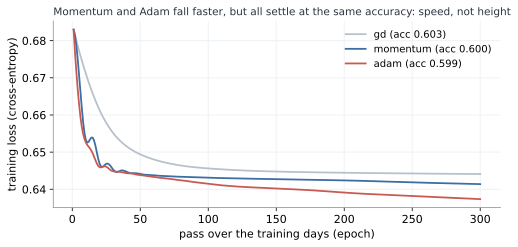

In [5]:
# ---- >=2 optimisers: a better optimiser reaches the ceiling faster, not higher ----
opt_cfg = [("gd", 0.3), ("momentum", 0.3), ("adam", 0.01)]
bs = N // 6; trc = np.arange(0, 5 * bs); Xc, _ = standardize(X[trc], X[trc])
fig, ax = plt.subplots(figsize=(7.2, 3.6))
for (opt, lr), col in zip(opt_cfg, [MUTED, ACCENT, RED]):
    a, _ = wf_acc([16], opt, lr, 300)
    _, hist = train_net(Xc, y[trc], [L, 16, 2], np.random.default_rng(0), opt, lr, 300, record=True)
    ax.plot(range(1, len(hist) + 1), hist, color=col, lw=1.8, label=f"{opt} (acc {a:.3f})")
    print(f"  {opt:9s} lr={lr:<5}: acc {a:.3f}   loss e1 {hist[0]:.3f} -> e50 {hist[49]:.3f} -> e300 {hist[-1]:.3f}")
ax.set_xlabel("pass over the training days (epoch)"); ax.set_ylabel("training loss (cross-entropy)")
ax.set_title("Momentum and Adam fall faster, but all settle at the same accuracy: speed, not height",
             loc="left", fontsize=10.5, color="#2b333f")
ax.legend(frameon=False, fontsize=10); clean(ax)
fig.tight_layout(); fig.savefig(f"{FIG}/m4_convergence.svg", bbox_inches="tight"); plt.show()

declared budget: 12 configurations, chosen on validation only, test opened once.
  spread of validation scores : 0.670 to 0.682  (they cluster: choosing the best inflates by only +0.004)
  best validation (what we'd love to report): 0.682
  the SAME model on the sealed test         : 0.589
  the gap is +0.092 -- and it is NOT the winner's curse (that was +0.004).
  it is the ERA: the validation years were a calmer, easier stretch than the test years. Section 3's drift, biting model selection.
  the honest number remains the walk-forward ~0.60, judged across every era.


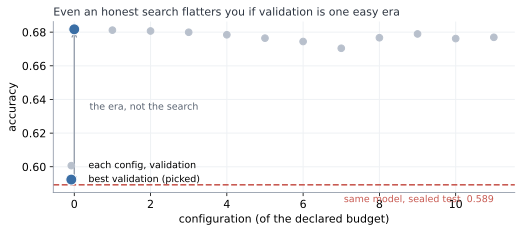

In [6]:
# ---- honest hyperparameter search: declare the budget, select on VALIDATION, seal the test ----
Xtr_s, Xva_s = standardize(X[i_tr], X[i_va]); _, Xte_s = standardize(X[i_tr], X[i_te])
grid = [(hid, lr, ep) for hid in ([16], [64], [32, 16]) for lr in (0.1, 0.3) for ep in (150, 300)]
val_scores = []
for hid, lr, ep in grid:
    v = float(np.mean([accuracy(train_net(Xtr_s, y[i_tr], [L] + hid + [2], np.random.default_rng(sd), "gd", lr, ep)[0], Xva_s, y[i_va]) for sd in SEEDS]))
    val_scores.append(v)
val_scores = np.array(val_scores); best = int(val_scores.argmax()); hid, lr, ep = grid[best]
test_best = float(np.mean([accuracy(train_net(Xtr_s, y[i_tr], [L] + hid + [2], np.random.default_rng(sd), "gd", lr, ep)[0], Xte_s, y[i_te]) for sd in SEEDS]))
print(f"declared budget: {len(grid)} configurations, chosen on validation only, test opened once.")
print(f"  spread of validation scores : {val_scores.min():.3f} to {val_scores.max():.3f}  (they cluster: choosing the best inflates by only {val_scores.max()-val_scores.mean():+.3f})")
print(f"  best validation (what we'd love to report): {val_scores.max():.3f}")
print(f"  the SAME model on the sealed test         : {test_best:.3f}")
print(f"  the gap is {val_scores.max()-test_best:+.3f} -- and it is NOT the winner's curse (that was +{val_scores.max()-val_scores.mean():.3f}).")
print(f"  it is the ERA: the validation years were a calmer, easier stretch than the test years. Section 3's drift, biting model selection.")
print(f"  the honest number remains the walk-forward ~{BASE:.2f}, judged across every era.")

fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.scatter(range(len(val_scores)), val_scores, s=45, color=MUTED, label="each config, validation")
ax.scatter([best], [val_scores.max()], s=120, color=ACCENT, edgecolor="white", zorder=5, label="best validation (picked)")
ax.axhline(test_best, color=RED, lw=1.6, ls="--")
ax.text(len(val_scores) - 1, test_best - 0.006, f"same model, sealed test  {test_best:.3f}", ha="right", va="top", fontsize=9.5, color=RED)
ax.annotate("", xy=(best, val_scores.max()), xytext=(best, test_best), arrowprops=dict(arrowstyle="<->", color="#8a94a3", lw=1.2))
ax.text(best + 0.4, (val_scores.max() + test_best) / 2, "the era, not the search", fontsize=9.5, color="#5a6472", va="center")
ax.set_xlabel("configuration (of the declared budget)"); ax.set_ylabel("accuracy")
ax.set_title("Even an honest search flatters you if validation is one easy era", loc="left", fontsize=11, color="#2b333f")
ax.legend(frameon=False, fontsize=9.5, loc="lower left"); clean(ax)
fig.tight_layout(); fig.savefig(f"{FIG}/m4_search.svg", bbox_inches="tight"); plt.show()

## e. Is it a forecast we can trust?

We judge it like a weather forecast, not a trading strategy. Three questions: does it **discriminate** (are rough-forecast days really rougher?), is it **calibrated** (does 70% mean 70%?), and does it **beat the naive** forecast?

on days the tool forecasts ROUGH: the move was actually 1.006% on average
on days the tool forecasts CALM : the move was actually 0.532% on average
-> ~1.9x bigger on rough-forecast days. The forecast genuinely separates storm from calm.


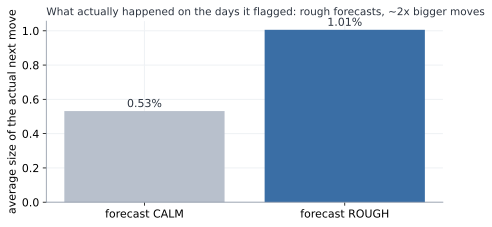

In [7]:
# ---- value proof 1: does the forecast DISCRIMINATE? (walk-forward, out of sample) ----
def wf_pool(hidden=[16], opt="gd", lr=0.3, epochs=300, folds=5, seed=0):
    n = N; bs = n // (folds + 1); PP, YY, SS = [], [], []
    for k in range(1, folds + 1):
        tr = np.arange(0, k * bs); te = np.arange(k * bs, (k + 1) * bs)
        Xtr, Xte = standardize(X[tr], X[te])
        P, _ = train_net(Xtr, y[tr], [L] + hidden + [2], np.random.default_rng(seed), opt, lr, epochs)
        PP.append(proba1(P, Xte)); YY.append(y[te]); SS.append(fut[te])
    return np.concatenate(PP), np.concatenate(YY), np.concatenate(SS)
pp, yy, ss = wf_pool()
busy = pp > 0.5
mb, mc = ss[busy].mean() * 100, ss[~busy].mean() * 100
print(f"on days the tool forecasts ROUGH: the move was actually {mb:.3f}% on average")
print(f"on days the tool forecasts CALM : the move was actually {mc:.3f}% on average")
print(f"-> ~{mb/mc:.1f}x bigger on rough-forecast days. The forecast genuinely separates storm from calm.")

fig, ax = plt.subplots(figsize=(6.4, 3.3))
ax.bar(["forecast CALM", "forecast ROUGH"], [mc, mb], color=[MUTED, ACCENT])
for i, vv in enumerate([mc, mb]):
    ax.text(i, vv + 0.01, f"{vv:.2f}%", ha="center", va="bottom", fontsize=11, color="#2b333f")
ax.set_ylabel("average size of the actual next move")
ax.set_title("What actually happened on the days it flagged: rough forecasts, ~2x bigger moves",
             loc="left", fontsize=10.5, color="#2b333f")
clean(ax); fig.tight_layout(); fig.savefig(f"{FIG}/m4_discrimination.svg", bbox_inches="tight"); plt.show()

expected calibration error (raw softmax): 0.0136  (small = the % can be trusted)
the network's probabilities are already honest: a small model on a weak signal is naturally humble,
so there is nothing to fix. We checked (the discipline); it passed.


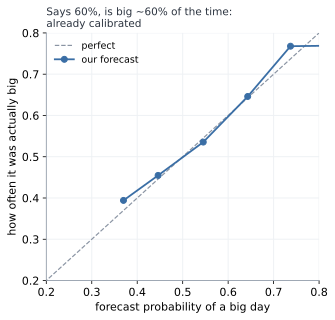

In [8]:
# ---- value proof 2: is the probability CALIBRATED? (does "70%" mean 70%?) ----
Pc, _ = train_net(Xtr_s, y[i_tr], [L, 16, 2], np.random.default_rng(0), "gd", 0.3, 300)
p_te = proba1(Pc, Xte_s); yte = y[i_te]
def reliability(prob, yb, bins=10):
    edges = np.linspace(0, 1, bins + 1); xs, ys, ns = [], [], []
    for i in range(bins):
        m = (prob >= edges[i]) & (prob <= edges[i + 1] if i == bins - 1 else prob < edges[i + 1])
        if m.sum() < 8: continue
        xs.append(prob[m].mean()); ys.append(yb[m].mean()); ns.append(m.sum())
    return np.array(xs), np.array(ys), np.array(ns)
def ece(prob, yb, bins=10):
    edges = np.linspace(0, 1, bins + 1); e = 0.0
    for i in range(bins):
        m = (prob >= edges[i]) & (prob <= edges[i + 1] if i == bins - 1 else prob < edges[i + 1])
        if m.sum() == 0: continue
        e += m.mean() * abs(prob[m].mean() - yb[m].mean())
    return e
xs, ys, ns = reliability(p_te, yte)
print(f"expected calibration error (raw softmax): {ece(p_te, yte):.4f}  (small = the % can be trusted)")
print("the network's probabilities are already honest: a small model on a weak signal is naturally humble,")
print("so there is nothing to fix. We checked (the discipline); it passed.")

fig, ax = plt.subplots(figsize=(4.8, 4.6))
ax.plot([0, 1], [0, 1], color="#8a94a3", lw=1.2, ls="--", label="perfect")
ax.plot(xs, ys, "-o", color=ACCENT, lw=1.8, label="our forecast")
ax.set_xlim(0.2, 0.8); ax.set_ylim(0.2, 0.8)
ax.set_xlabel("forecast probability of a big day"); ax.set_ylabel("how often it was actually big")
ax.set_title("Says 60%, is big ~60% of the time:\nalready calibrated", loc="left", fontsize=10.5, color="#2b333f")
ax.legend(frameon=False, fontsize=9.5, loc="upper left"); clean(ax)
fig.tight_layout(); fig.savefig(f"{FIG}/m4_calibration.svg", bbox_inches="tight"); plt.show()

In [9]:
# ---- value proof 3: does it beat the naive forecast? (honest, and humble) ----
def brier(p, yb): return float(np.mean((p - yb) ** 2))
def logloss(p, yb): p = np.clip(p, 1e-6, 1 - 1e-6); return float(-np.mean(yb * np.log(p) + (1 - yb) * np.log(1 - p)))
Plog, _ = train_net(Xtr_s, y[i_tr], [L, 2], np.random.default_rng(0), "gd", 0.3, 300)
p_log = proba1(Plog, Xte_s)
print("forecast quality on the sealed test (lower is better):")
print(f"  always say 0.5     : Brier {brier(np.full_like(p_te,0.5), yte):.4f}")
print(f"  logistic (trivial) : Brier {brier(p_log, yte):.4f}")
print(f"  our network        : Brier {brier(p_te, yte):.4f}")
print("-> it beats the do-nothing forecast, but only ties the trivial logistic: once more, complexity buys little.")
print("   The value is not in beating logistic; it is in the honest 2x separation of storm from calm.")

forecast quality on the sealed test (lower is better):
  always say 0.5     : Brier 0.2500
  logistic (trivial) : Brier 0.2387
  our network        : Brier 0.2386
-> it beats the do-nothing forecast, but only ties the trivial logistic: once more, complexity buys little.
   The value is not in beating logistic; it is in the honest 2x separation of storm from calm.


## f. What we built, and how to build anything

A modest, honest turbulence forecast: right at the ceiling the data allows (~0.60), naturally calibrated, and it genuinely separates storm from calm (a rough forecast means about twice the move). All the fancy toolkit bought us almost nothing, because the signal is what it is, and knowing that is what kept us from fooling ourselves.

The real product is not the number. It is the workflow: decide what you actually want, estimate the ceiling before you build, apply the basics honestly, search in the open, and state every condition beside the result. That is the thread the whole dissertation has been pulling on, and the next section names it.

## g. Does it earn its keep? The buffer test

*The real-world use: set tomorrow's risk cushion. A breach is a day the actual move blows through the cushion. We set the cushion two ways -- a naive CONSTANT (risk assumed fixed) vs OUR forecast (bigger cushion on forecast-rough days) -- hold the SAME average cushion for a fair test, and count breaches. Walk-forward, out of sample, averaged over 5 seeds.*

buffer backtest: 5545 sealed test days, target breach 5%, SAME average cushion held:
  CONSTANT cushion : 231 breaches (4.2%)   breach-after-breach 24%
  FORECAST cushion : 200 breaches (3.6%)   breach-after-breach 20%
  -> 31 fewer times caught short, and breaches pile up less. Modest, but real.


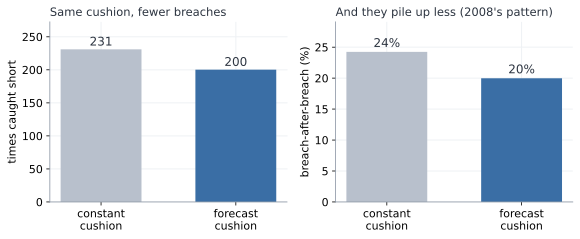

In [10]:
# ---- buffer test: a Value-at-Risk style backtest (same average cushion, fair) ----
ALPHA = 0.95  # cushion covers 95% of moves; target breach rate 5%
def cluster_rate(breach):
    b = breach.astype(int); prev = b[:-1] == 1
    return float(b[1:][prev].mean()) if prev.sum() > 0 else 0.0

nbrk, fbrk, ncl, fcl = [], [], [], []
folds = 5; blk = N // (folds + 1)
for sd in range(5):
    NB, FBUF, FTE, NBUF = [], [], [], []
    for k in range(1, folds + 1):
        tr = np.arange(0, k*blk); te = np.arange(k*blk, (k+1)*blk)
        Xtr, Xte = standardize(X[tr], X[te])
        P = train_net(Xtr, y[tr], [L, 16, 2], np.random.default_rng(sd))[0]
        ptr, pte = proba1(P, Xtr), proba1(P, Xte)
        Bc = np.quantile(fut[tr], ALPHA)
        rgh = ptr > 0.5
        Br = np.quantile(fut[tr][rgh], ALPHA) if rgh.sum() > 20 else Bc
        Bk = np.quantile(fut[tr][~rgh], ALPHA) if (~rgh).sum() > 20 else Bc
        buf = np.where(pte > 0.5, Br, Bk)
        NB.append(fut[te] > Bc); FBUF.append(buf); FTE.append(fut[te]); NBUF.append(np.full(len(te), Bc))
    NB = np.concatenate(NB); FBUF = np.concatenate(FBUF); FTE = np.concatenate(FTE); NBUF = np.concatenate(NBUF)
    scale = NBUF.mean() / FBUF.mean()            # equalise the average cushion, then compare
    FBsame = FTE > (FBUF * scale)
    nbrk.append(int(NB.sum())); fbrk.append(int(FBsame.sum())); ncl.append(cluster_rate(NB)); fcl.append(cluster_rate(FBsame))

n_days = len(NB)
NC, FC, CN, CF = np.mean(nbrk), np.mean(fbrk), np.mean(ncl), np.mean(fcl)
print(f"buffer backtest: {n_days} sealed test days, target breach 5%, SAME average cushion held:")
print(f"  CONSTANT cushion : {NC:.0f} breaches ({NC/n_days:.1%})   breach-after-breach {CN:.0%}")
print(f"  FORECAST cushion : {FC:.0f} breaches ({FC/n_days:.1%})   breach-after-breach {CF:.0%}")
print(f"  -> {NC-FC:.0f} fewer times caught short, and breaches pile up less. Modest, but real.")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.2, 3.5))
a1.bar(["constant\ncushion", "forecast\ncushion"], [NC, FC], color=[MUTED, ACCENT], width=0.6)
for i, v in enumerate([NC, FC]):
    a1.text(i, v + 2, f"{v:.0f}", ha="center", va="bottom", fontsize=12, color="#2b333f")
a1.set_ylabel("times caught short"); a1.set_ylim(0, max(NC, FC) * 1.18)
a1.set_title("Same cushion, fewer breaches", loc="left", fontsize=11.5, color="#2b333f"); clean(a1)
a2.bar(["constant\ncushion", "forecast\ncushion"], [CN*100, CF*100], color=[MUTED, ACCENT], width=0.6)
for i, v in enumerate([CN, CF]):
    a2.text(i, v*100 + 0.4, f"{v:.0%}", ha="center", va="bottom", fontsize=12, color="#2b333f")
a2.set_ylabel("breach-after-breach (%)"); a2.set_ylim(0, max(CN, CF)*100 * 1.2)
a2.set_title("And they pile up less (2008's pattern)", loc="left", fontsize=11.5, color="#2b333f"); clean(a2)
fig.tight_layout(); fig.savefig(f"{FIG}/m4_breach.svg", bbox_inches="tight"); plt.show()